In [ ]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [ ]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: []


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import zipfile

zip_path = "/content/plantdisease.zip"   # change name if needed
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done")

FileNotFoundError: [Errno 2] No such file or directory: '/content/plantdisease.zip'

In [ ]:
import zipfile

zip_path = "/content/archive (2).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done")

BadZipFile: File is not a zip file

In [ ]:
import os
print(os.listdir("/content"))

['.config', 'archive (2).zip', 'sample_data']


In [5]:
import os

file_path = "/content/archive (2).zip"
print("Size:", os.path.getsize(file_path) / (1024*1024), "MB")

Size: 657.5705432891846 MB


In [6]:
import zipfile

with zipfile.ZipFile("/content/archive (2).zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Extraction Done")

Extraction Done


In [7]:
import os

print(os.listdir("/content/dataset"))

['plantvillage', 'PlantVillage']


In [8]:
import os

print(os.listdir("/content/dataset/PlantVillage"))

['Potato___Early_blight', 'Pepper__bell___healthy', 'Tomato__Tomato_mosaic_virus', 'Potato___healthy', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Bacterial_spot', 'Pepper__bell___Bacterial_spot', 'Tomato_Leaf_Mold', 'Tomato_Late_blight', 'Potato___Late_blight', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Target_Spot', 'Tomato_Septoria_leaf_spot']


In [9]:
import os
import shutil
import random

source_dir = "/content/dataset/PlantVillage"
base_dir = "/content/data_split"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

split_ratio = 0.8  # 80% train, 20% val

for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)

    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        random.shuffle(images)

        split_index = int(len(images) * split_ratio)
        train_images = images[:split_index]
        val_images = images[split_index:]

        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

        for img in train_images:
            shutil.copy(os.path.join(class_path, img),
                        os.path.join(train_dir, class_name, img))

        for img in val_images:
            shutil.copy(os.path.join(class_path, img),
                        os.path.join(val_dir, class_name, img))

print("Dataset split complete!")

Dataset split complete!


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 16   # keep smaller for stability

train_dir = "/content/data_split/train"
val_dir = "/content/data_split/val"

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size
)

Found 16504 images belonging to 15 classes.
Found 4134 images belonging to 15 classes.


In [11]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,215,474 (16.08 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [12]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3
)

Epoch 1/3
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 101s 70ms/step - accuracy: 0.1504 - loss: 2.5793 - val_accuracy: 0.1553 - val_loss: 2.5669
Epoch 2/3
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.1546 - loss: 2.5716 - val_accuracy: 0.1553 - val_loss: 2.5706
Epoch 3/3
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.1555 - loss: 2.5703 - val_accuracy: 0.1553 - val_loss: 2.5663


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 16

train_dir = "/content/data_split/train"
val_dir = "/content/data_split/val"

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size
)

Found 16504 images belonging to 15 classes.
Found 4134 images belonging to 15 classes.


In [15]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# 🔥 IMPORTANT FIX (UNFREEZE LAST LAYERS)
for layer in base_model.layers[-20:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])

In [16]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,215,474 (16.08 MB)

 Trainable params: 4,173,451 (15.92 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [17]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 216s 134ms/step - accuracy: 0.8670 - loss: 0.4725 - val_accuracy: 0.2129 - val_loss: 3.2215
Epoch 2/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 86s 83ms/step - accuracy: 0.9702 - loss: 0.0905 - val_accuracy: 0.3716 - val_loss: 2.0863
Epoch 3/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 86s 84ms/step - accuracy: 0.9850 - loss: 0.0498 - val_accuracy: 0.3229 - val_loss: 2.2770
Epoch 4/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 86s 84ms/step - accuracy: 0.9871 - loss: 0.0406 - val_accuracy: 0.7281 - val_loss: 0.8796
Epoch 5/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 141s 83ms/step - accuracy: 0.9890 - loss: 0.0325 - val_accuracy: 0.6018 - val_loss: 1.5455


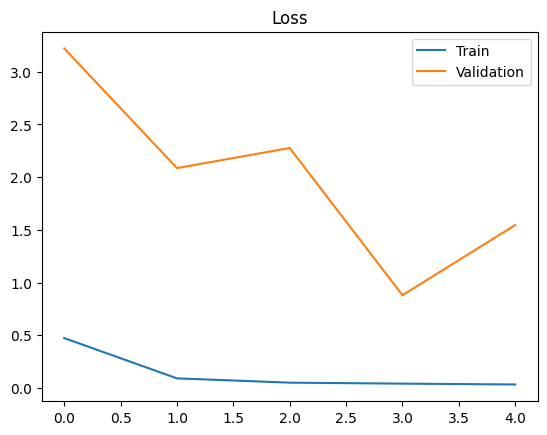

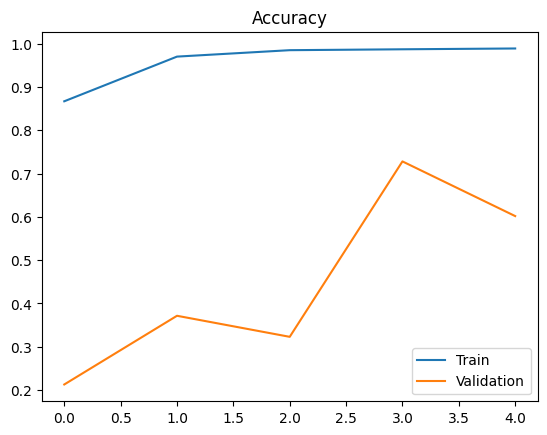

In [18]:
import matplotlib.pyplot as plt

# Loss
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()
plt.show()

# Accuracy
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()
plt.show()

In [19]:
model.save("plant_model.h5")

In [20]:
from google.colab import files
files.download("plant_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

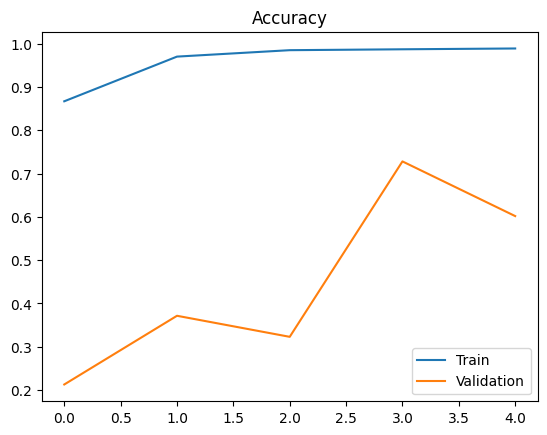

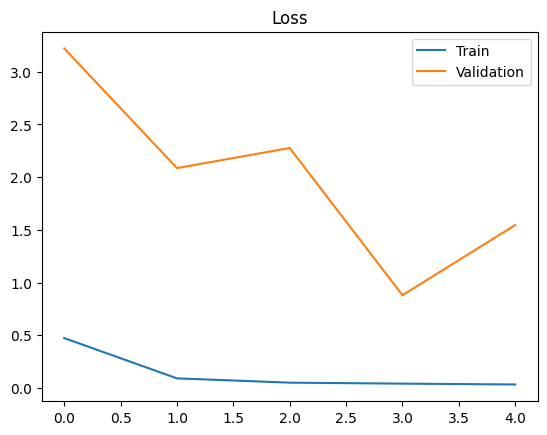

In [21]:
import matplotlib.pyplot as plt

# Save Accuracy graph
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()
plt.savefig("accuracy.png")
plt.show()

# Save Loss graph
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()
plt.savefig("loss.png")
plt.show()